Renda familiar × desempenho

Neste notebook buscamos analisar em como a renda familiar do estudante influencia seu desempenho no ENEM?

Através da variável Q006 (que representa a renda mensal familiar) em relação às notas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

#carregamento dos dois anos 
df_2019 = pd.read_parquet('../../dados-processados/enem2019_RS_SP.parquet')
df_2023 = pd.read_parquet('../../dados-processados/enem2023_RS_SP.parquet')
df = pd.concat([df_2019, df_2023], ignore_index=True)

#filtro de presença nos 2 dias
presentes = (df['TP_PRESENCA_CN']==1) & (df['TP_PRESENCA_CH']==1) & \
            (df['TP_PRESENCA_LC']==1) & (df['TP_PRESENCA_MT']==1)
df = df[presentes].copy()

#nota media
areas = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
df['NOTA_MEDIA'] = df[areas].mean(axis=1)

print(f"Base de análise: {len(df):,} participantes presentes nos 2 dias")

Base de análise: 1,258,720 participantes presentes nos 2 dias


## Varivael Q006

A variável Q006 (renda familiar) usa faixas realcionadas no salário mínimo do ano, não em valores nominais fixos. 

Em 2019 o salário mínimo era R$ 998 e, em 2023, R$ 1.320.

Isso significa que a letra `B` em 2019 representa "até R$ 998", enquanto em 2023 representa "até R$ 1.320" (mas as duas correspondem a mesam posicao). Por isso, comparar a mesma letra entre anos não esta errado.


A escala completa em múltiplos de salário mínimo:

| Letra | Múltiplos de SM | 2019 (R$) | 2023 (R$) |
|---|---|---|---|
| A | Sem renda | 0 | 0 |
| B | Até 1 SM | até 998 | até 1.320 |
| C | 1 a 1,5 SM | 998 – 1.497 | 1.320 – 1.980 |
| D | 1,5 a 2 SM | 1.497 – 1.996 | 1.980 – 2.640 |
| E | 2 a 2,5 SM | 1.996 – 2.495 | 2.640 – 3.300 |
| ... | ... | ... | ... |
| P | 15 a 20 SM | 14.970 – 19.960 | 19.800 – 26.400 |
| Q | Acima de 20 SM | acima de 19.960 | acima de 26.400 |

In [2]:
#define a ordem das faixas e cria um rótulo humanizado (múltiplos de SM)
ordem_q006 = list('ABCDEFGHIJKLMNOPQ')

rotulos_sm = {
    'A':'Sem renda', 'B':'Até 1 SM', 'C':'1–1,5 SM', 'D':'1,5–2 SM', 'E':'2–2,5 SM',
    'F':'2,5–3 SM', 'G':'3–4 SM', 'H':'4–5 SM', 'I':'5–6 SM', 'J':'6–7 SM',
    'K':'7–8 SM', 'L':'8–9 SM', 'M':'9–10 SM', 'N':'10–12 SM', 'O':'12–15 SM',
    'P':'15–20 SM', 'Q':'>20 SM'
}

df['Q006_label'] = df['Q006'].map(rotulos_sm)

#distribuição dos participantes por faixa de renda
distribuicao = df['Q006'].value_counts().reindex(ordem_q006)
print("Quantos participantes em cada faixa de renda (total agregado):\n")
print(distribuicao)

Quantos participantes em cada faixa de renda (total agregado):

Q006
A     20978
B    128568
C    228833
D    154298
E    150393
F     87441
G    134140
H     82349
I     58468
J     39437
K     30053
L     21215
M     19739
N     27397
O     24007
P     21583
Q     29821
Name: count, dtype: int64


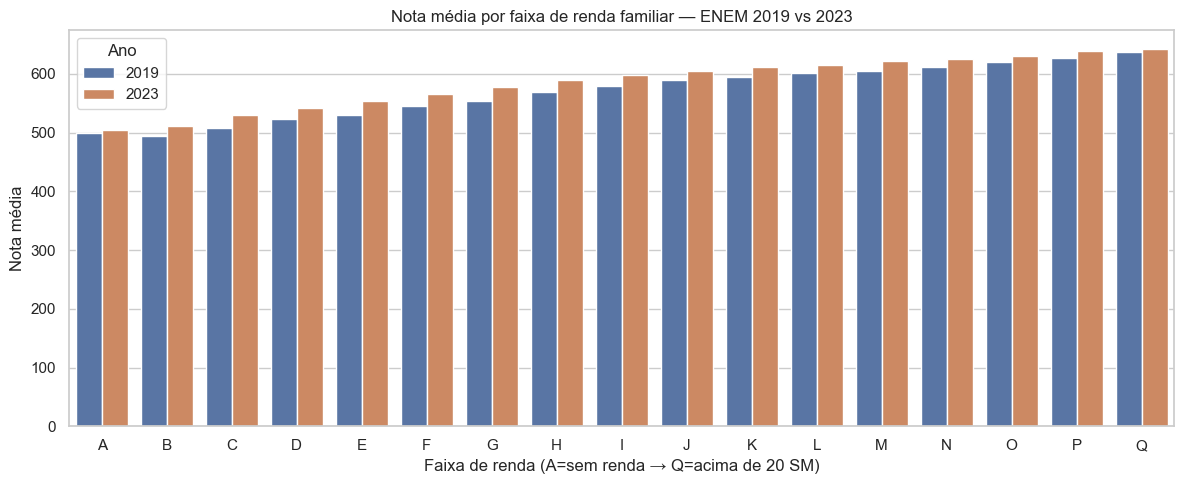

NU_ANO,2019,2023
Q006,,
A,500.1,505.0
B,494.1,511.9
C,507.8,529.4
D,522.8,541.7
E,530.3,554.3
F,545.5,565.8
G,553.4,577.4
H,569.9,589.5
I,578.7,598.0


In [3]:
#nota media por faixa e por ano
medias = df.groupby(['NU_ANO','Q006'])['NOTA_MEDIA'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=medias, x='Q006', y='NOTA_MEDIA', hue='NU_ANO',
            order=ordem_q006, palette=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Nota média por faixa de renda familiar — ENEM 2019 vs 2023')
ax.set_xlabel('Faixa de renda (A=sem renda → Q=acima de 20 SM)')
ax.set_ylabel('Nota média')
ax.legend(title='Ano')
plt.tight_layout()
plt.show()

#tabela com os nros
medias.pivot(index='Q006', columns='NU_ANO', values='NOTA_MEDIA').round(1).reindex(ordem_q006)

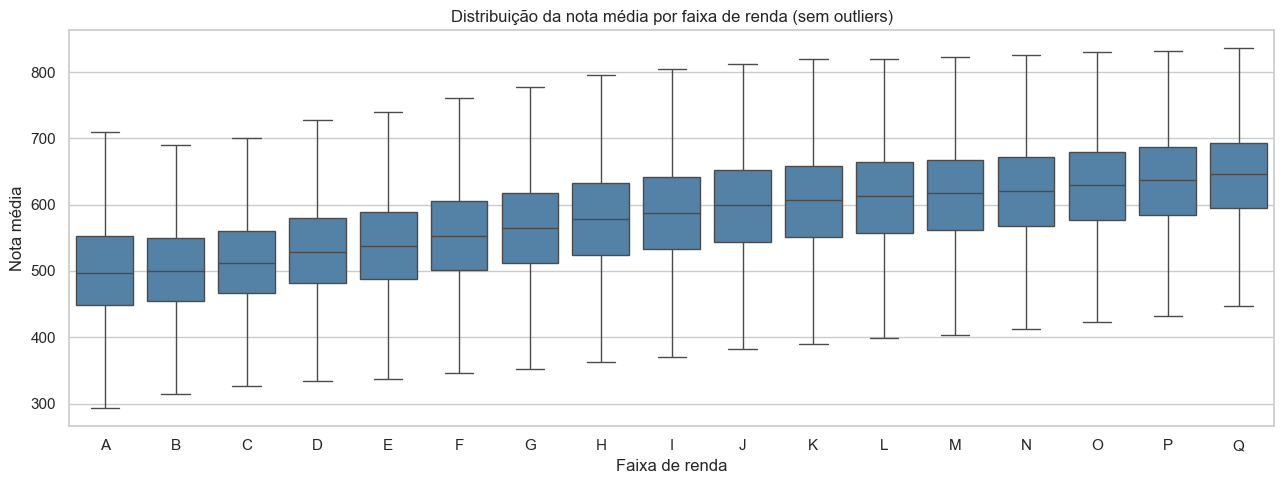

In [4]:
#boxplot para ver a média e a distribuição inteira
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x='Q006', y='NOTA_MEDIA', order=ordem_q006,
            color='steelblue', ax=ax, showfliers=False) #showfliers=False para tirar os outliers e ver melhor a tendencia central
ax.set_title('Distribuição da nota média por faixa de renda (sem outliers)')
ax.set_xlabel('Faixa de renda')
ax.set_ylabel('Nota média')
plt.tight_layout()
plt.show()

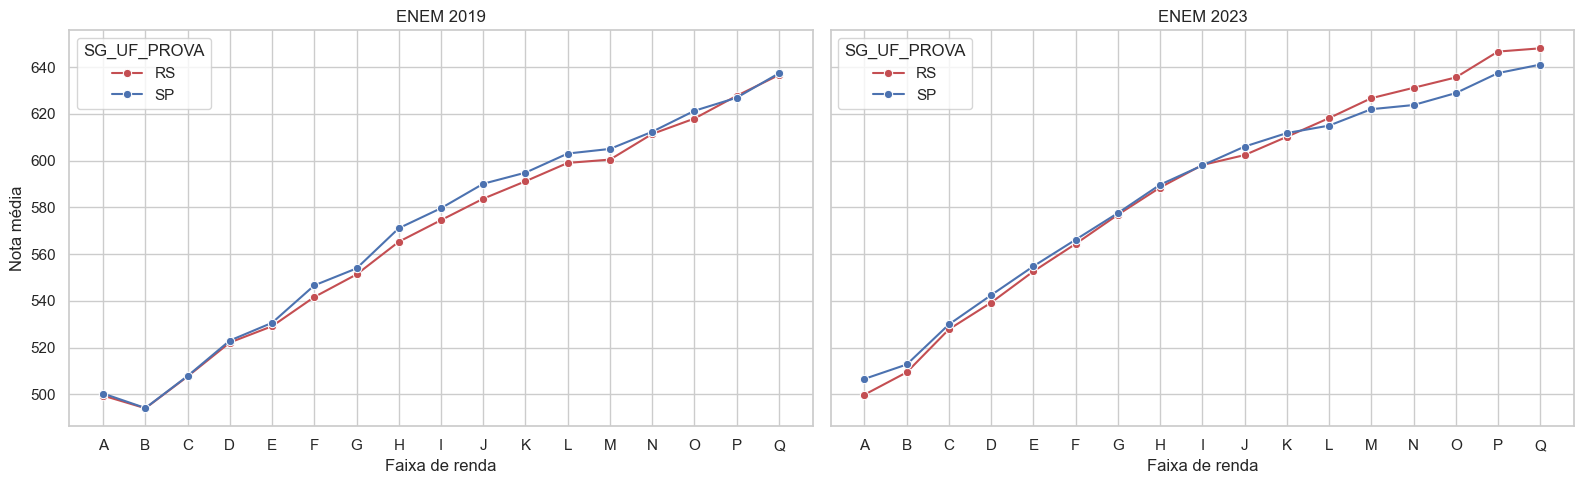

In [5]:
#analise da relacao entre renda e desempenho por estado

medias_uf = df.groupby(['NU_ANO','SG_UF_PROVA','Q006'])['NOTA_MEDIA'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, ano in zip(axes, [2019, 2023]):
    sub = medias_uf[medias_uf['NU_ANO']==ano]
    sns.lineplot(data=sub, x='Q006', y='NOTA_MEDIA', hue='SG_UF_PROVA',
                 marker='o', ax=ax, palette=['#C44E52','#4C72B0'])
    ax.set_title(f'ENEM {ano}')
    ax.set_xlabel('Faixa de renda')
    ax.set_ylabel('Nota média')
    #reordena o eixo x na ordem das letras
    ax.set_xticks(range(len(ordem_q006)))
    ax.set_xticklabels(ordem_q006)

plt.tight_layout()
plt.show()

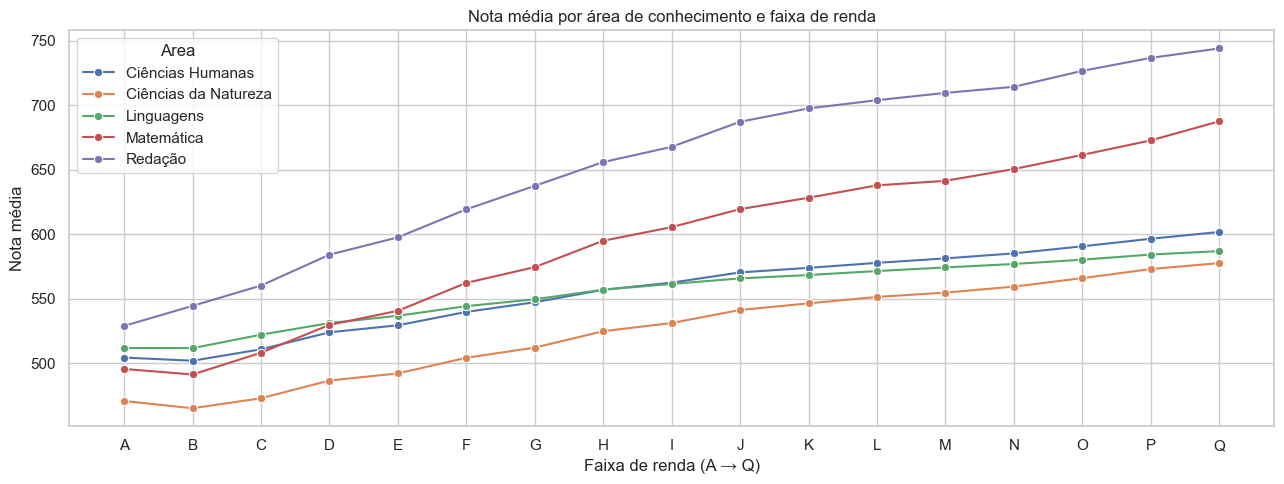

In [6]:
#nota media por area e faixa de renda nos dois anos
areas_label = {'NU_NOTA_CN':'Ciências da Natureza', 'NU_NOTA_CH':'Ciências Humanas',
               'NU_NOTA_LC':'Linguagens', 'NU_NOTA_MT':'Matemática',
               'NU_NOTA_REDACAO':'Redação'}

dados_area = df.melt(id_vars=['Q006'], value_vars=list(areas_label.keys()),
                     var_name='Area', value_name='Nota')
dados_area['Area'] = dados_area['Area'].map(areas_label)
dados_area = dados_area.dropna(subset=['Nota'])

medias_area = dados_area.groupby(['Area','Q006'])['Nota'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=medias_area, x='Q006', y='Nota', hue='Area',
             marker='o', ax=ax)
ax.set_title('Nota média por área de conhecimento e faixa de renda')
ax.set_xlabel('Faixa de renda (A → Q)')
ax.set_ylabel('Nota média')
ax.set_xticks(range(len(ordem_q006)))
ax.set_xticklabels(ordem_q006)
plt.tight_layout()
plt.show()


In [7]:
#analise para verificar qual a diferença entre o topo (Q) e a base (A) em cada area
gap = medias_area.pivot(index='Area', columns='Q006', values='Nota')
gap['Diferença Q–A'] = (gap['Q'] - gap['A']).round(1)
gap[['A','Q','Diferença Q–A']].sort_values('Diferença Q–A', ascending=False)

Q006,A,Q,Diferença Q–A
Area,,,
Redação,528.903613,743.961638,215.1
Matemática,495.551811,687.451313,191.9
Ciências da Natureza,470.715602,577.588257,106.9
Ciências Humanas,504.383955,601.706452,97.3
Linguagens,511.827214,586.880500,75.1
